# Интеллектуальный анализ данных – весна 2025

# Домашнее задание 7: Деревья. Случайный лес

Правила:

- Домашнее задание оценивается в 10 баллов.


- Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.


- Можно использовать любые свободные источники с обязательным указанием ссылки на них.


- Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

<!-- ![](meme.jpg) -->
<img src="meme.jpg" alt="Drawing" style="width: 700px;"/>

## Часть 1: Основы построения решающие дерева (1.5 балла)

В этой части все расчёты необходимо реализовывать в виде запрограммированных формул, например, на `numpy`. **Нельзя использовать готовые реализации**. Например, если в задании требуется рассчитать энтропию, то требуется в каком-то виде релизовать расчёт по формуле, но нельзя использовать готовую реализацию `some_module.entropy()`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**Задание 1.1 (0.5 балла)** Пусть известно, что в вершину решающего дерева попали 10 объектов, 8 из которых имеют метку класса $k_1$, а 2 имеют метку класса $k_2$. Рассчитайте энтропию такого распределения классов (с натуральным логарифмом). Ответ округлите до двух знаков после запятой.

In [2]:
p = np.array([0.8, 0.2])
entr = - np.sum(p*np.log(p))
entr = np.round(entr, 2)
entr

0.5

**Задание 1.2 (0.5 балла)** Пусть дополнительно известно, что вершина из предыдущего задания не является листовой и возможно такое разбиение, что в левое поддерево попадут все объекты класса $k_1$, а в правое - класса $k_2$. Посчитайте критерий информативности:

$$
Q(R_m, j, t) = H(R_m) - \frac{|R_\ell|}{|R_m|}H(R_\ell) - \frac{|R_r|}{|R_m|}H(R_r),
$$

где $R_m$ - множество объектов в разбиваемой вершине, $j$ - номер признака, по которому происходит разбиение, $t$ - порог разбиения, $R_\ell$ - множество объектов в левом поддереве, $R_r$ - множество объектов в правом поддереве.

Теперь в качестве $H(R)$ будем использовать индекс Джини:

$$
H(R) = \sum_{k=1}^J p_k(1-p_k),
$$
где $J$ – общее количество классов (в нашем случае, $J = 2$).

Ответ округлите до двух знаков после запятой.

In [3]:
def gini(p):
    return np.sum(p*(1 - p))

Rm = 10
Rl = 8
Rr = 2

p = np.array([0.8, 0.2])
H_Rm = gini(p)

p_l = np.array([1, 0])
p_r = np.array([0, 1])
H_Rl= gini(p_l)
H_Rr = gini(p_r)

Q = H_Rm - (Rl / Rm)*H_Rl - (Rr / Rm)*H_Rr
Q = np.round(Q, 2)
Q

0.32

**Задание 1.3 (0.5 балла)** Пусть при построении дерева образовалась листовая вершина с 10 объектами, значения целевой переменной для которых следующие: [1, 10, 5, 18, 100, 30, 50, 61, 84, 47] (решается задача регрессии). Чему будут равны предсказания модели для этих объектов?

In [4]:
n = 10
target = np.array([1, 10, 5, 18, 100, 30, 50, 61, 84, 47])
answer = np.mean(target)
answer

40.6

## Часть 2: Решающие деревья (4.5 балла)

В этой части мы напишем и протестируем собственную реализацию решающего дерева.

In [5]:
from collections import Counter
from typing import Dict, List, Tuple, Union

**Задание 2.1 (1.5 балла)** Реализуйте функцию `find_best_split()`, которая должна находить оптимальное разбиение подмножества обучающей выборки в соответствии с информационным критерием из **Задания 1.2**. В качестве меры хаотичности $H(R)$ для задачи регрессии испольуйте дисперсию подвыборки, а для задачи классификации – критерий Джини (определён в том же задании).

Для категориальных признаков применяется наивный алгоритм разбиения: мы пытаемся найти одно значение, разбиение по которому сильнее всего увеличит критерий информативности. Иными словами, объекты с конкретным значением признака отправляем в левое поддерево, остальные - в правое. Обратите внимание, что это далеко не оптимальные способ учёта категориальных признаков. Например, можно было бы на каждое значение категориального признака создавать отдельное поддерево или использовать более сложные подходы. Подробнее об этом можно прочитать в конспектах [лекций](https://github.com/esokolov/ml-course-hse/blob/master/2019-fall/lecture-notes/lecture07-trees.pdf) по машинному обучению на ПМИ (раздел «Учёт категориальных признаков»).

В качестве подсказок реализации можете пользоваться кодом из бонусной части семинара по решающим деревьям.

**Бонус:** Разрешается делать цикл для перебора порогов, но возможна имплементация без него. За имплементацию без цикла – **бонус 1 балл**.

In [67]:
import numpy as np
import pandas as pd

def gini(y):
    classes, counts = np.unique(y, return_counts=True) #классы, частоты каждого из классов в вершине
    #classes - уникальные значения классов, отсортированные по возрастанию
    n = counts.sum() #количество объектов в вершине
    p = counts / n #вероятности каждого из классов в вершине
    return np.sum(p*(1 - p)) #формула критерия Джини

def variance(y):
    return np.mean(y**2) - np.mean(y)**2 #формула дисперсии

def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame], 
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:
    """
    Указания:
    * Пороги, приводящие к попаданию в одно из поддеревьев пустого множества объектов, не рассматриваются.
    * В качестве порогов, нужно брать среднее двух сосдених (при сортировке) значений признака
    * Поведение функции в случае константного признака может быть любым.
    * При одинаковых приростах Джини или дисперсии нужно выбирать минимальный сплит.
    * За наличие в функции циклов балл будет снижен. Векторизуйте! :)

    :param feature_vector: вещественнозначный вектор значений признака
    :param target_vector: вектор классов объектов,  len(feature_vector) == len(target_vector)
    :param task: либо `classification`, либо `regression`
    :param feature_type: либо `real`, либо `categorical`
    
    :return thresholds: отсортированный по возрастанию вектор со всеми возможными порогами, по которым объекты можно
     разделить на две различные подвыборки, или поддерева
    :return ginis: вектор со значениями критерия Джини для каждого из порогов в thresholds len(ginis) == len(thresholds)
    :return threshold_best: оптимальный порог (число)
    :return gini_best: оптимальное значение критерия Джини (число)
    """

    #приводим feature_vector к одному типу данных
    if isinstance(feature_vector, pd.DataFrame):
        X = feature_vector.iloc[:, 0].values #берем только первый столбик
    elif isinstance(feature_vector, pd.Series):
        X = feature_vector.values
    else:
        X = feature_vector
    #X - признаки в формате np.ndarray

    #приводим target_vector к одному типу данных
    if isinstance(target_vector, pd.Series):
        y = target_vector.values
    else:
        y = target_vector
    #y - таргеты в формате np.ndarray

    #количество объектов в разбиваемой (исходной) вершине
    Rm = len(y)

    #обработка случая, когда входные данные пустые или там 1 объект
    if Rm <= 1:
        return np.array([]), np.array([]), None, None

    #вычисление меры хаотичности для разбиваемой вершины
    if task == "classification":
        H_Rm = gini(y) #критерий Джини для разбиваемой вершины
    else:
        H_Rm = variance(y) #дисперсия для разбиваемой вершины 

    #обработка вещественных признаков
    if feature_type == "real":

        #сортируем значения признака по возрастанию
        sorted_indexes = np.argsort(X) #индексы для сортировки
        sorted_X = X[sorted_indexes]
        
        #создаем массив с ответами, соответствующими отсортированным значениям признака
        sorted_y = y[sorted_indexes]
    
        #находим все возможные пороги
        thresholds = (sorted_X[0:-1] + sorted_X[1:]) / 2
        meaningless_thresholds = sorted_X[0:-1] == sorted_X[1:]
        thresholds = thresholds[~meaningless_thresholds]

        #обработка случая, когда признак является константным (вектор с порогами - пустой)
        if len(thresholds) == 0:
            return np.array([]), np.array([]), None, None

        #индексы, по которым будет производиться разбиение массива sorted_y (индексы объектов, начиная с которых объекты будут уходить в правое поддерево)
        split_indexes = np.arange(1, len(y))[~meaningless_thresholds]

        Q_list = []
        #последовательный перебор порогов
        for i in split_indexes:
            left_split = sorted_y[0:i]
            right_split = sorted_y[i:]

            Rl = len(left_split)
            Rr = len(right_split)

            #обработка случаев, когда разбиение по порогу приводит к попаданию в одно из поддеревьев пустого множества объектов
            #мы стремимся максимизировать Q, поэтому чтобы такие пороги не рассматривались используем минус бесконечность
            if len(left_split) == 0 or len(right_split) == 0:
                Q_list.append(-np.inf)
                continue

            if task == "classification":
                H_Rl = gini(left_split) #критерий Джини для левого поддерева 
                H_Rr = gini(right_split) #критерий Джини для правого поддерева 
            else:
                H_Rl = variance(left_split) #дисперсия для левого поддерева
                H_Rr = variance(right_split) #дисперсия для правого поддерева

            Q = H_Rm - (Rl / Rm)*H_Rl - (Rr / Rm)*H_Rr
            Q_list.append(Q)

        Q_list = np.array(Q_list)

    #обработка категориальных признаков
    else:  
        X_values = np.unique(X)
        thresholds = []
        Q_list = []

        #последовательный перебор "порогов" (значения признака, отделяемого от остальных)
        for val in X_values:
            mask_left = X == val
            mask_right = X != val

            #обработка случаев, когда разбиение по порогу приводит к попаданию в одно из поддеревьев пустого множества объектов или когда признак является константным
            if mask_left.sum() == 0 or mask_right.sum() == 0:
                continue

            left_split = y[mask_left] #1 значение признака
            right_split = y[mask_right] #все остальные

            Rl = len(left_split)
            Rr = len(right_split)
            
            if task == "classification":
                H_Rl = gini(left_split)
                H_Rr = gini(right_split)
            else:
                H_Rl = variance(left_split)
                H_Rr = variance(right_split)

            Q = H_Rm - (Rl / Rm)*H_Rl - (Rr / Rm)*H_Rr

            thresholds.append(val)
            Q_list.append(Q)

        thresholds = np.array(thresholds)
        Q_list = np.array(Q_list)

        #обработка случая, когда признак является константным (вектор с порогами - пустой)
        if len(thresholds) == 0:
            return np.array([]), np.array([]), None, None

    best_Q_index = np.argmax(Q_list) #индекс порога, при котором Q - максимальный
    threshold_best = thresholds[best_Q_index]
    Q_best = Q_list[best_Q_index]

    return thresholds, Q_list, threshold_best, Q_best

Эту функцию можно протестировать на датасете `California`.

In [68]:
from sklearn.datasets import fetch_california_housing

In [69]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [70]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

Выведите график зависимости значения критерия ошибки от порогового значения при разбиении вершины по признаку `MedInc`.

In [71]:
thresholds, Q_list, threshold_best, Q_best = find_best_split(X["MedInc"], y, task="regression", feature_type="real")

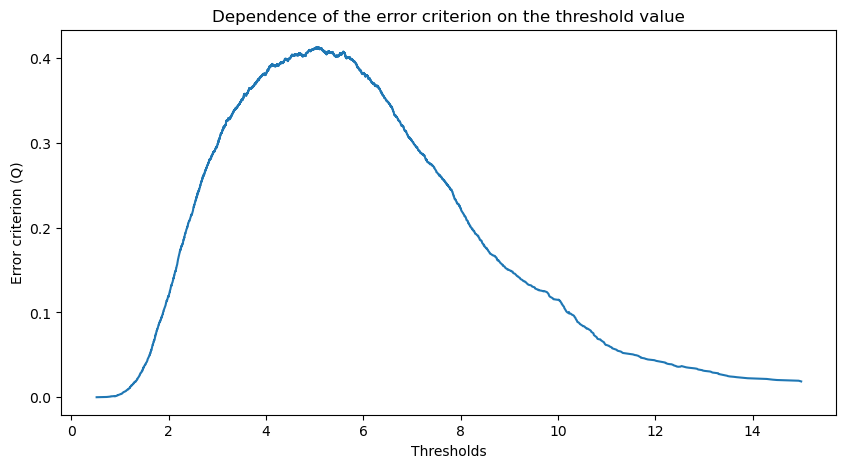

In [72]:
plt.figure(figsize=(10, 5))
plt.plot(thresholds, Q_list)
plt.title("Dependence of the error criterion on the threshold value")
plt.xlabel("Thresholds")
plt.ylabel("Error criterion (Q)")
plt.show()

Найдите лучший, с вашей точки зрения, предикат первой вершины решающего дерева.

In [73]:
info = {}
for feature in X.columns:
    thresholds, Q_list, threshold_best, Q_best = find_best_split(X[feature], y, task="regression", feature_type="real")
    info[feature] = Q_best

for feature, Q_best in info.items():
    if Q_best == max(info.values()):
        best_feature = feature

thresholds, Q_list, threshold_best, Q_best = find_best_split(X[best_feature], y, task="regression", feature_type="real")
best_feature_threshold = threshold_best

print(f'Лучший предикат первой вершины решающего дерева: [{best_feature} < {best_feature_threshold}]')

Лучший предикат первой вершины решающего дерева: [MedInc < 5.03515]


**Задание 2.2 (1 балл)** Разберитесь с написанным кодом решающего дерева, заполните пропуски в коде и реализуйте недостающий метод `_predict_node()`.

Построение дерева осуществляется согласно базовому жадному алгоритму, предложенному в лекции в разделе «Построение дерева».
- **Выбор лучшего разбиения** необходимо производить по критерию Джини.
- **Критерий останова:** все объекты в листе относятся к одному классу или ни по одному признаку нельзя разбить выборку.
- **Ответ в листе:** наиболее часто встречающийся класс в листе.

В задаче также предлагается получить два бонуса, по баллу на каждый!

- **Реализуйте способ обрабатывать пропуски в даннх и реализуйте его, пояснив свои действия.**
- **Реализуйте метод оценки важности признаков.**

In [81]:
class DecisionTree: #создание класса
    
    def __init__( #инициализация (конструктор класса)
        self, 
        feature_types: Union[List[str], np.ndarray], #типы признаков - категориальные (слова) или вещественные (числа)
        max_depth: int = None, #гиперпараметры (по умолчанию - ограничений нет)
        min_samples_split: int = None, 
        min_samples_leaf: int = None,
        task: str = "classification" #задача (по умолчанию - классификация)
    ) -> None:
        
        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))): #в случае неизвестного типа признака - ошибка
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}
        
        # типы признаков (категориальные или числовые)
        self._feature_types = feature_types
        
        # гиперпараметры дерева
        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task
        
        # Переменная, если вы решите делать бонус
        #важность признаков
        self._feature_importances = {i: 0.0 for i in range(len(feature_types))} 

    def _pass_missing(self, X: np.ndarray): #обработка пропусков
        X_new = X.copy()
        for i, f_type in enumerate(self._feature_types):
            column = X[:, i]
            if f_type == "real": #для вещественных признаков - заполнение средними
                mask = ~np.isnan(column)
                mean = np.mean(column[mask])
                column[np.isnan(column)] = mean
            elif f_type == "categorical": #для категориальных - "unknown"
                column = np.where(pd.isnull(column), "unknown", column)
            X_new[:, i] = column
        return X_new
            
    def _fit_node(
        self, 
        sub_X: np.ndarray, #выборка или подвыборка, передаваемые для разбиения
        sub_y: np.ndarray,
        node: dict #словарь с информацией о разбиваемой вершине дерева
    ) -> None:
        
        # критерий останова
        if np.all(sub_y == sub_y[0]): #если все элементы одинаковые,
            node["type"] = "terminal" #то это листовая вершина
            node["class"] = sub_y[0] #предсказание (класс)
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None #создание переменных
        for feature in range(sub_X.shape[1]): #перебор признаков
            feature_type = self._feature_types[feature] #получение его типа

            # подготавливаем признак для поиска оптимального порога
            if feature_type == "real": 
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                # здесь могла быть реализация более сложного подхода к обработке категориального признака
                feature_vector = sub_X[:, feature]

            # ищем оптимальный порог
            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type) #получение лучшего порога и максимума критерия информативности
            
            if gini is not None and (gini_best is None or gini > gini_best):
                feature_best = feature #лучший признак
                gini_best = gini #лучший Q

                # split - маска на объекты, которые должны попасть в левое поддерево
                if feature_type == "real":
                    threshold_best = threshold
                    split = feature_vector < threshold 
                elif feature_type == "categorical":
                    # в данной реализации это просто значение категории
                    threshold_best = threshold
                    split = feature_vector == threshold
                else:
                    raise ValueError

        # записываем полученные сплиты в атрибуты класса
        if feature_best is None: #если разбиение не найдено,
            node["type"] = "terminal" #то это листовая вершина
            node["class"] = Counter(sub_y).most_common(1)[0][0] #голосование большинством
            return

        self._feature_importances[feature_best] += gini_best #признак использовался в разбиении
        
        node["type"] = "nonterminal" #разбиение найдено

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError
            
        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node["type"] == "terminal":
            return node["class"]

        feature = node["feature_split"]
        feature_type = self._feature_types[feature]

        if feature_type == "real":
            threshold = node["threshold"]
            if x[feature] < threshold:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

        elif feature_type == "categorical":
            category = node["category_split"]
            if x[feature] == category:
                return self._predict_node(x, node["left_child"])
            else:
                return self._predict_node(x, node["right_child"])

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        X = self._pass_missing(X)
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        X = self._pass_missing(X)
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))     
        return np.array(predicted)

    def feature_importances(self):
        total = sum(self._feature_importances.values()) #сумма вклада всех признаков
        if total == 0:
            return {k: 0.0 for k in self._feature_importances}
        return {k: v / total for k, v in self._feature_importances.items()} #доля признаков в общем вкладе

**Задание 2.3 (1 балл)** Загрузите таблицу `students.csv` (это немного преобразованный датасет [User Knowledge](https://archive.ics.uci.edu/ml/datasets/User+Knowledge+Modeling)). В ней признаки объекта записаны в первых пяти столбцах, а в последнем записана целевая переменная (класс: 0 или 1). Постройте на одном изображении пять кривых "порог — значение критерия Джини" для всех пяти признаков. Отдельно визуализируйте диаграммы рассеяния "значение признака — класс" для всех пяти признаков.

In [82]:
df = pd.read_csv('students.csv')
X = df.iloc[:, 0:6]
y = df.iloc[:, -1]
X = X[X.columns.drop('Unnamed: 0')]
X.head()

,STG,SCG,STR,LPR,PEG
0,0.00,0.00,0.00,0.00,0.00
1,0.08,0.08,0.10,0.24,0.90
2,0.06,0.06,0.05,0.25,0.33
3,0.10,0.10,0.15,0.65,0.30
4,0.08,0.08,0.08,0.98,0.24


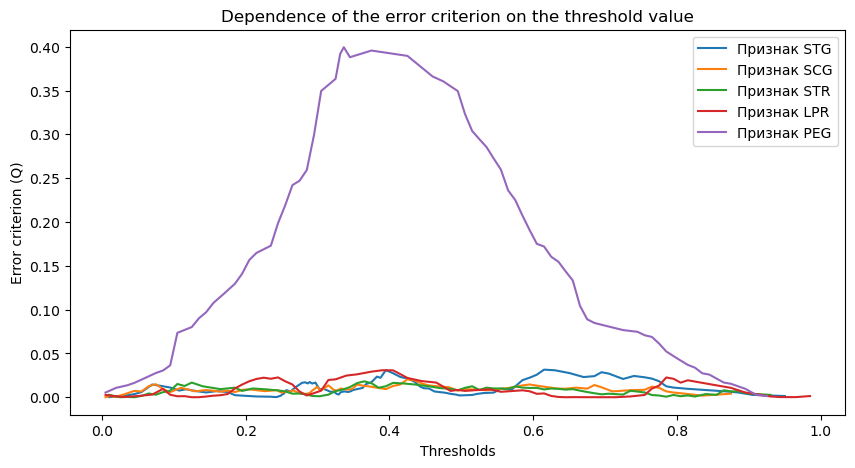

In [83]:
plt.figure(figsize=(10, 5))
features = X.columns
res = [find_best_split(X[feature], y, task="classification", feature_type="real") for feature in features]

thresholds_list, Q_list_list, threshold_best_list, Q_best_list = zip(*res)

[plt.plot(thresholds, Q_list, label=f"Признак {feature}") 
for thresholds, Q_list, feature in zip(thresholds_list, Q_list_list, features)]
plt.title("Dependence of the error criterion on the threshold value")
plt.xlabel("Thresholds")
plt.ylabel("Error criterion (Q)")
plt.legend()
plt.show()

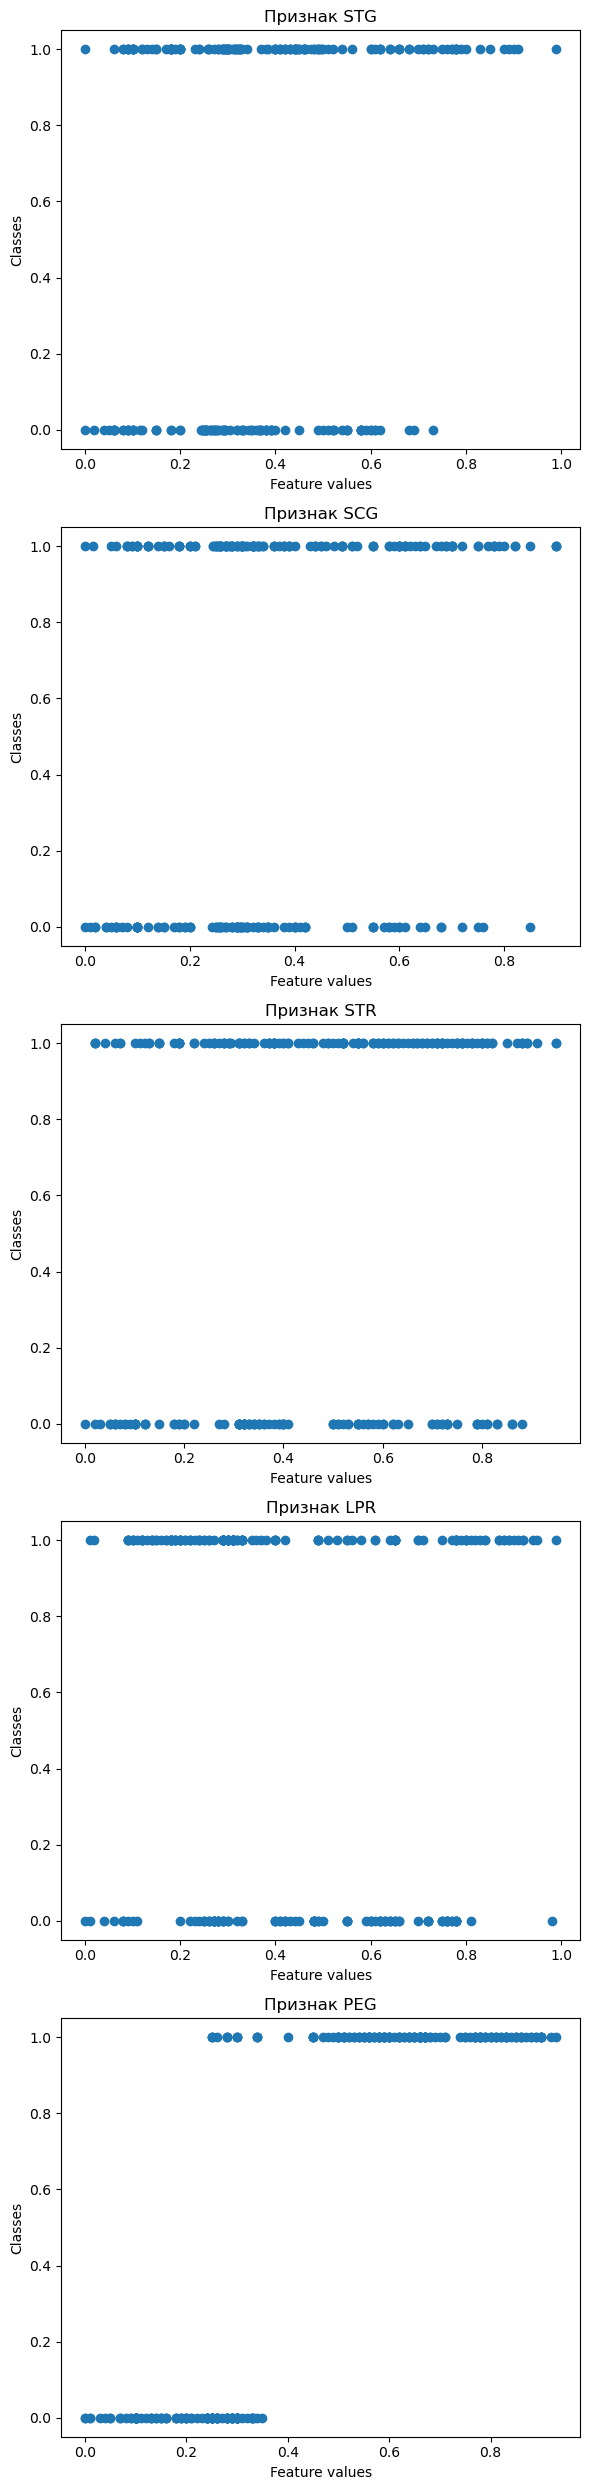

In [84]:
plt.figure(figsize=(6, 25))
for i, feature in enumerate(features):
    plt.subplot(5, 1, i+1)
    plt.scatter(X[feature], y)
    plt.title(f"Признак {feature}")
    plt.xlabel("Feature values")
    plt.ylabel("Classes")

plt.tight_layout()
plt.show()

Исходя из кривых значений критерия Джини, по какому признаку нужно производить деление выборки на два поддерева? Согласуется ли этот результат с визуальной оценкой диаграмм рассеяиния? Как бы охарактеризовали вид кривой для "хороших" признаков, по которым выборка делится почти идеально? Чем отличаются кривые для признаков, по которым деление практически невозможно?

Ответ:

Так как мы стремимся максимизировать Q, то деление выборки на 2 поддерева нужно производить по признаку "PEG". Такой результат согласуется с визуальной оценкой диаграмм рассеяния, т.к. для признака "PEG" можно выбрать порог, который почти идеально разделит объекты по классам. Вид кривой для "хороших" признаков будет иметь ярко выраженный пик (максимум), а для "плохих" - прямая или кривая без ярко выраженных подъемов.

**Задание 2.4 (1 балл)** Протестируйте свое решающее дерево на датасете [mushrooms](https://archive.ics.uci.edu/ml/datasets/Mushroom). 

1. Скачайте таблицу `agaricus-lepiota.data` (из [Data Folder](https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/)), 
2. Считайте таблицу при помощи `pandas`,
3. Примените к каждому столбцу `LabelEncoder` (из `sklearn`), чтобы преобразовать строковые имена категорий в натуральные числа. 

Первый столбец — это целевая переменная (e — edible, p — poisonous) Мы будем измерять качество с помощью accuracy, так что нам не очень важно, что будет классом 1, а что — классом 0. Обучите решающее дерево на половине случайно выбранных объектов (признаки в датасете категориальные) и сделайте предсказания для оставшейся половины. Вычислите accuracy.

In [85]:
from sklearn.model_selection import train_test_split

y = table["p"]
X = table[table.columns.drop("p")]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=True)

In [86]:
from sklearn.preprocessing import LabelEncoder

X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

for column in X_train.columns:
    enc = LabelEncoder()
    X_train_encoded[column] = enc.fit_transform(X_train[column])
    X_test_encoded[column] = enc.transform(X_test[column])

y_enc = LabelEncoder()
y_train_encoded = y_enc.fit_transform(y_train)
y_test_encoded = y_enc.transform(y_test)

In [88]:
from sklearn.metrics import accuracy_score

feature_types = ["categorical"] * X_train_encoded.shape[1]

X_train_np = X_train_encoded.values
X_test_np = X_test_encoded.values

DT = DecisionTree(feature_types=feature_types)
DT.fit(X_train_np, y_train_encoded)

y_pred = DT.predict(X_test_np)

print(accuracy_score(y_test_encoded, y_pred))

1.0


## Часть 3: Бэггинг и случайный лес (4 балла)

В данной части мы будем работать [с задачей предсказания диабета у пациента](https://www.kaggle.com/uciml/pima-indians-diabetes-database/data). Посмотрим на работу бэггинга над решающими деревьями и случайного леса, сравним их работу.

In [89]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [90]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

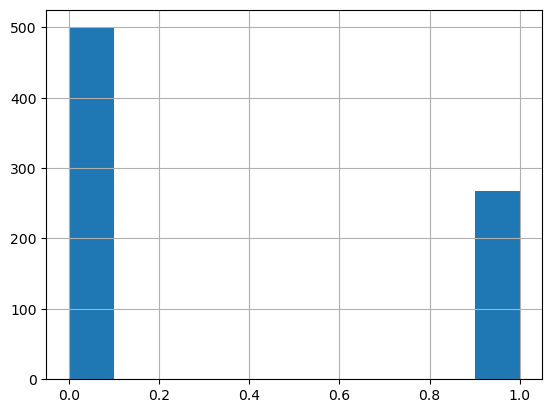

In [91]:
data['Outcome'].hist()
plt.show()

**Задание 3.1 (0.5 балла)** Разделите данные на признаки и целевую переменную. Разбейте датасет на обучающую и тестовую части в отношении 7:3. Затем разделите обучающую выборку на обучающую-обучающую и обучающую-валидационную в соотношении 7:3 (то есть в итоге должно получиться три выборки: обучающая-обучающая (0.49 от исходного датасета), обучающая-валидационная (0.21 от исходного датасета) и тестовая (0.3 от исходного датасета).

In [92]:
X = data[data.columns.drop("Outcome")] #признаки
y = data["Outcome"] #целевая переменная
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train_train, X_train_val, y_train_train, y_train_val = train_test_split(X_train, y_train, test_size=0.3, random_state=0)

**Задание 3.2 (1 балл)** На обучающей-валидационной выборке подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_leaf` для `DecisionTreeClassifier`. Для этого:
1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений обучите дерево на обучающей-обучающей выборке и определите качество на обучающей-валидационной выборке. В качестве критерия будем использовать `f1-меру`.
3. Выберите ту пару значений, которая даёт наилучшее качество на обучающей-валидационной выборке. 


Обучите решающее дерево с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по метрикам `accuracy`, `precision` и `recall`, `auc_roc`.

In [93]:
from sklearn.metrics import f1_score

In [94]:
max_depth_list = [1, 3, 5, 10]
min_samples_leaf_list = [5, 10, 15, 20]

for i, max_depth in enumerate(max_depth_list):
    for j, min_samples_leaf in enumerate(min_samples_leaf_list):
        dt = DecisionTreeClassifier(
            max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=0
        )
        dt.fit(X_train_train, y_train_train)
        y_pred_val = dt.predict(X_train_val)
        print(f'max_depth = {max_depth}, min_samples_leaf = {min_samples_leaf}')
        print(F'f1_score on validation sample: {np.round(f1_score(y_train_val, y_pred_val), 3)}') 
        print()

max_depth = 1, min_samples_leaf = 5
f1_score on validation sample: 0.589

max_depth = 1, min_samples_leaf = 10
f1_score on validation sample: 0.589

max_depth = 1, min_samples_leaf = 15
f1_score on validation sample: 0.589

max_depth = 1, min_samples_leaf = 20
f1_score on validation sample: 0.589

max_depth = 3, min_samples_leaf = 5
f1_score on validation sample: 0.523

max_depth = 3, min_samples_leaf = 10
f1_score on validation sample: 0.565

max_depth = 3, min_samples_leaf = 15
f1_score on validation sample: 0.578

max_depth = 3, min_samples_leaf = 20
f1_score on validation sample: 0.578

max_depth = 5, min_samples_leaf = 5
f1_score on validation sample: 0.571

max_depth = 5, min_samples_leaf = 10
f1_score on validation sample: 0.591

max_depth = 5, min_samples_leaf = 15
f1_score on validation sample: 0.661

max_depth = 5, min_samples_leaf = 20
f1_score on validation sample: 0.661

max_depth = 10, min_samples_leaf = 5
f1_score on validation sample: 0.587

max_depth = 10, min_samples_

Наилучшее качество на обучающей-валидационной выборке (F1-мера = 0.661) дали следующие комбинации значений гиперпараметров:
- max_depth = 5, min_samples_leaf = 15;
- max_depth = 5, min_samples_leaf = 20;
- max_depth = 10, min_samples_leaf = 20.

Чтобы избежать риска переобучения стоит выбрать меньшую глубину (max_depth = 5) и большее количество объектов в листах (min_samples_leaf = 20).

In [95]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=0)
        
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

print(F'Accuracy on test sample: {np.round(accuracy_score(y_test, y_pred), 3)}')
print(F'Precision on test sample: {np.round(precision_score(y_test, y_pred), 3)}')
print(F'Recall on test sample: {np.round(recall_score(y_test, y_pred), 3)}')
print(F'AUC-ROC on test sample: {np.round(roc_auc_score(y_test, y_pred), 3)}')

Accuracy on test sample: 0.762
Precision on test sample: 0.711
Recall on test sample: 0.432
AUC-ROC on test sample: 0.675


**Задание 3.3 (0.5 балла)** Обучите [`BaggingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) на 50 деревьях на **полной обучающей** выборке. Оцените качество классификации на тестовой выборке по тем же метрикам.

In [96]:
clf = BaggingClassifier(n_estimators=50, random_state=0)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(F'Accuracy on test sample: {np.round(accuracy_score(y_test, y_pred), 3)}')
print(F'Precision on test sample: {np.round(precision_score(y_test, y_pred), 3)}')
print(F'Recall on test sample: {np.round(recall_score(y_test, y_pred), 3)}')
print(F'AUC-ROC on test sample: {np.round(roc_auc_score(y_test, y_pred), 3)}')

Accuracy on test sample: 0.779
Precision on test sample: 0.689
Recall on test sample: 0.568
AUC-ROC on test sample: 0.723


**Задание 3.4 (1 балл)** Выполните кросс-валидацию на полной обучающей выборке и подберите оптимальные значения гиперпараметров `max_depth` и `min_samples_split` для `Random Forest` с 50 деревьями. Для этого:

1. Создайте списки с возможными значениями для перебора.
2. Для каждой пары значений проведите кросс-валидацию на полной обучающей выборке. Количество разбиений выберите на ваш вкус. В качестве критерия будем использовать `f1-меру`. Усредните значение критерия по всем прогонам кросс-валидации. 
3. Выберите ту пару значений, которая даёт наилучшее среднее качество. 

Обучите случайный лес с подобранными гиперпараметрами на **полной обучающей** выборке. Оцените качество классификации по тем же метрикам. Какая из трёх построенных моделей показала себя лучше?

In [97]:
from sklearn.model_selection import cross_val_score

In [98]:
max_depth_list = [1, 3, 5, 10]
min_samples_split_list = [2, 6, 10, 16, 20]

for i, max_depth in enumerate(max_depth_list):
    for j, min_samples_split in enumerate(min_samples_split_list):
        rf = RandomForestClassifier(n_estimators=50, max_depth=max_depth, min_samples_split=min_samples_split, random_state=0)
        scores = cross_val_score(rf, X_train, y_train, cv = 10, scoring='f1')
        av_score = np.round(np.mean(scores), 3)

        print(f'max_depth = {max_depth}, min_samples_split = {min_samples_split}')
        print(F'f1_score on train sample: {av_score}') 
        print()

max_depth = 1, min_samples_split = 2
f1_score on train sample: 0.181

max_depth = 1, min_samples_split = 6
f1_score on train sample: 0.181

max_depth = 1, min_samples_split = 10
f1_score on train sample: 0.181

max_depth = 1, min_samples_split = 16
f1_score on train sample: 0.181

max_depth = 1, min_samples_split = 20
f1_score on train sample: 0.181

max_depth = 3, min_samples_split = 2
f1_score on train sample: 0.587

max_depth = 3, min_samples_split = 6
f1_score on train sample: 0.57

max_depth = 3, min_samples_split = 10
f1_score on train sample: 0.589

max_depth = 3, min_samples_split = 16
f1_score on train sample: 0.564

max_depth = 3, min_samples_split = 20
f1_score on train sample: 0.562

max_depth = 5, min_samples_split = 2
f1_score on train sample: 0.603

max_depth = 5, min_samples_split = 6
f1_score on train sample: 0.606

max_depth = 5, min_samples_split = 10
f1_score on train sample: 0.625

max_depth = 5, min_samples_split = 16
f1_score on train sample: 0.622

max_depth = 5

Наилучшее среднее качество (F1-мера = 0.629) дает max_depth = 10 и min_samples_split = 16.

In [99]:
rf = RandomForestClassifier(n_estimators=50, max_depth=10, min_samples_split=16, random_state=0)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(F'Accuracy on test sample: {np.round(accuracy_score(y_test, y_pred), 3)}')
print(F'Precision on test sample: {np.round(precision_score(y_test, y_pred), 3)}')
print(F'Recall on test sample: {np.round(recall_score(y_test, y_pred), 3)}')
print(F'AUC-ROC on test sample: {np.round(roc_auc_score(y_test, y_pred), 3)}')

Accuracy on test sample: 0.784
Precision on test sample: 0.731
Recall on test sample: 0.514
AUC-ROC on test sample: 0.712


Ответ:

Распределение целевой переменной неравномерное, поэтому для определения качества моделей на accuracy особо не стоит смотреть, т.к. она не учитывает дисбаланс классов, цену ошибки на объектах разных классов и для бинарной классификации будет высоким  за счет большой доли True Negatie. Однако, стоит отметить, что во всех 3 моделях эта метрика превышает долю негативных объектов (самый популярный класс), что говорит о том, что каждый из алгоритмов является разумным. Наибольшая accuracy (0.784) получилась у случайного леса, затем идет бэггинг (0.779) и решающее дерево (0.762).

Задача - предсказание диабета у пациента, поэтому нам важнее верно находить объекты положительного класса (важнее recall, а не precision). Наибольший recall - у бэггинга (0.568 против 0.514 у случайного леса и 0.432 у решающего дерева): модель находит больше положительных объектов, чем случайный лес и решающее дерево, а также обладает наибольшим AUC-ROC (0.723 против 0.712 у случайного леса и 0.675 у дерева), т.е. лучше разделяет классы, чем другие 2 модели.

Таким образом, учитывая контекст задачи, бэггинг показал себя лучше других 2 моделей.


**Задание 3.5 (0.5 балла)** Постройте график зависимости AUC ROC на тестовой выборке от числа деревьев (`n_estimators`) для случайного леса, обучаемого на **полной обучающей** выборке. Какие выводы можно сделать?

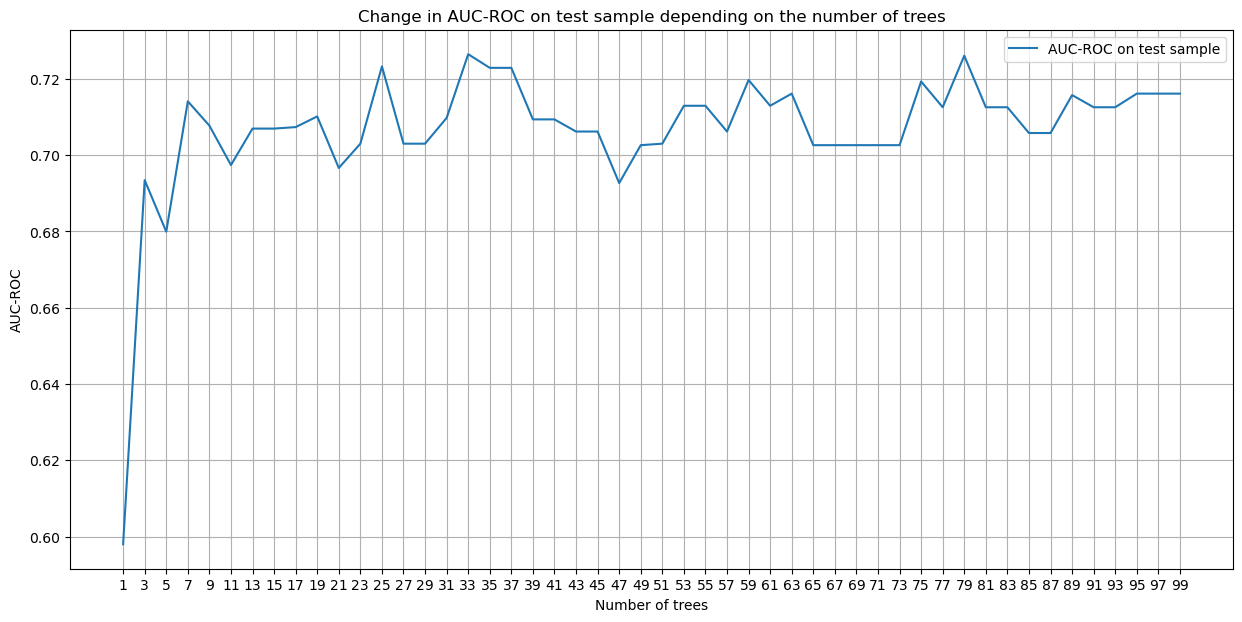

In [100]:
n_trees = 100
test_auc_roc = []

for i in range(1, n_trees, 2):
    rf = RandomForestClassifier(n_estimators=i, random_state=0, n_jobs=4)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    test_auc_roc.append(roc_auc_score(y_test, y_pred))

plt.figure(figsize=(15, 7))
plt.title("Сhange in AUC-ROC on test sample depending on the number of trees")
plt.grid()
plt.plot(test_auc_roc, label="AUC-ROC on test sample")
plt.xticks(ticks=range(len(test_auc_roc)), labels=range(1, n_trees, 2))
plt.ylabel("AUC-ROC")
plt.xlabel("Number of trees")
plt.legend()
plt.show()

Ответ:

Сначала на графике происходит резкое увеличение AUC-ROC, что говорит о том, что с добавлением деревьев разброс модели уменьшается и она все менее становится подвержена переобучению, она становится устойчивее. Далее при увеличении количества деревьев AUC-ROC изменяется не сильно, значения AUC-ROC стабилизируются, а колебания связаны со случайностью композиции. Исходя из получившегося графика можно сделать вывод о том, что оптимальное значение этой метрики качества можно подобрать.

**Задание 3.6 (0.5 балла)** Для лучшей модели случайного леса из **Задания 3.4** посчитайте важность признаков и постройте bar plot. Какой признак оказался самым важным для определения диабета?

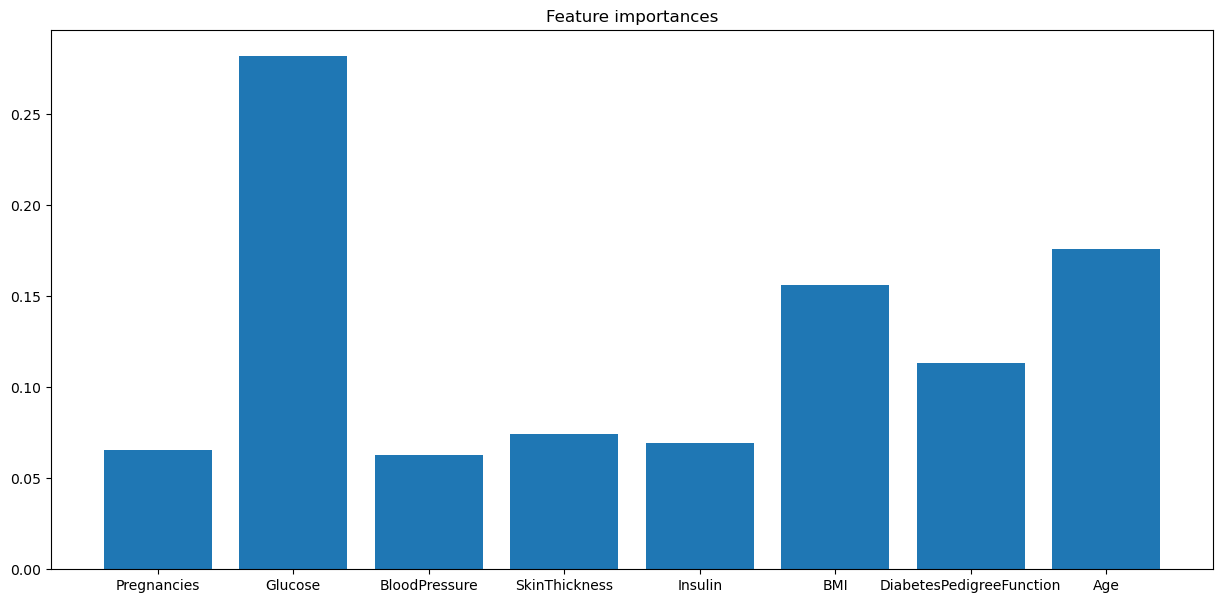

In [101]:
rf = RandomForestClassifier(n_estimators=50, max_depth=10, min_samples_split=16, random_state=0)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

plt.figure(figsize=(15, 7))
plt.title("Feature importances")
plt.bar(X.columns, rf.feature_importances_)
plt.show()

Ответ:

Самым важным оказался признак "Glucose", соответствующий концентрации глюкозы в плазме крови через 2 часа после теста на толерантность к глюкозе, что вполне обоснованно, так как диабет характеризуется патологически высоким уровнем сахара (глюкозы) в крови из-за нарушения секреции гормона инсулина. 